In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

%matplotlib inline

np.random.seed(1)

# Little boilerplate code to find out if we have a gpu
device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")
print(f'Device: {device}')

Cuda installed! Running on GPU!
Device: cuda


In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets

train_dataset = dsets.MNIST(root='./data', 
                            train=True, 
                            transform=transforms.ToTensor(),
                            download=True)

test_dataset = dsets.MNIST(root='./data', 
                           train=False, 
                           transform=transforms.ToTensor())


batch_size = 100
n_iters = 3000
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)

## Visualization

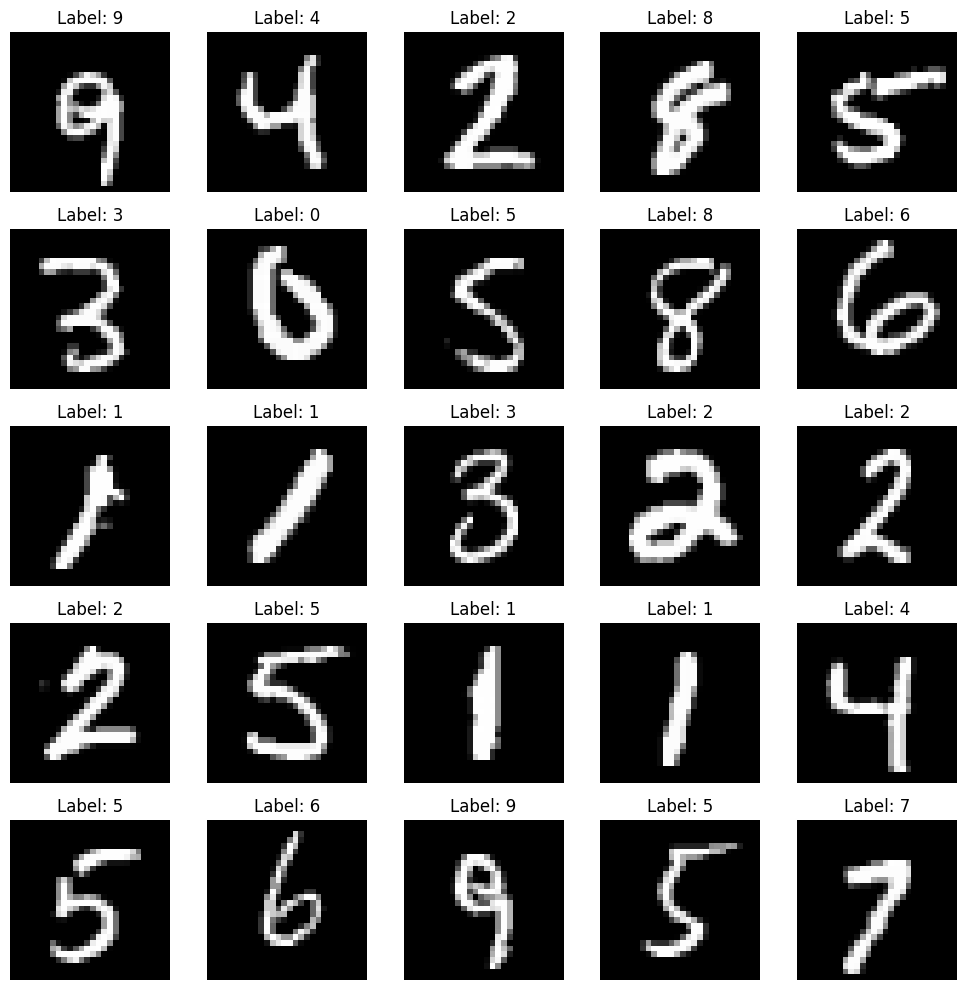

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure and axis with 5x5 dimensions
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()  # Flatten the axes array for easy indexing

# Loop through the train_loader to get samples
for i, (images, labels) in enumerate(train_loader):
    if i == 25:  # Only plot 25 images
        break
    
    # Display each image in the corresponding subplot
    ax = axes[i]
    ax.imshow(images[i].squeeze(), cmap='gray')  # Use squeeze to remove unnecessary dimensions
    ax.set_title(f'Label: {labels[i]}')
    ax.axis('off')  # Turn off axis labels

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## Create GAN Model


In [4]:
class Generator(nn.Module):
    def __init__(self,latent_dim,img_shape):
        super(Generator, self).__init__()

        def block(in_feat, out_feat, normalize=True):
            layers = [nn.Linear(in_feat, out_feat)]
            if normalize:
                layers.append(nn.BatchNorm1d(out_feat, 0.8))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(latent_dim, 128, normalize=False),
            *block(128, 256),
            *block(256, 512),
            *block(512, 1024),
            nn.Linear(1024, int(np.prod(img_shape))),
            nn.Sigmoid()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), *img_shape)
        return img

In [5]:
class Discriminator(nn.Module):
    def __init__(self,img_shape):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(int(np.prod(img_shape)), 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)

        return validity

In [6]:
# Loss function
adversarial_loss = torch.nn.BCELoss()

# Initialize generator and discriminator
latent_dim = 200
img_size = 28
channels = 1
img_shape = (channels, img_size, img_size)

generator = Generator(latent_dim,img_shape).to(device)
discriminator = Discriminator(img_shape).to(device)

# Optimizers
lr =1e-4
b1=0.5
b2=0.99
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))


In [7]:

from torch.autograd import Variable
cuda = True if torch.cuda.is_available() else False
Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor

print("Start training GAE...")
epochs = 100

for epoch in range(epochs):
    glossall = 0
    dlossall = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        
        # Adversarial ground truths
        valid = Variable(Tensor(x.size(0), 1).fill_(1.0), requires_grad=False)
        fake = Variable(Tensor(x.size(0), 1).fill_(0.0), requires_grad=False)

        # Configure input
        real_imgs = Variable(x.type(Tensor))

        # -----------------
        #  Train Generator
        # -----------------

        optimizer_G.zero_grad()

        # Sample noise as generator input
        z = Variable(Tensor(np.random.normal(0, 1, (x.shape[0], latent_dim))))

        # Generate a batch of images
        gen_imgs = generator(z)

        # Loss measures generator's ability to fool the discriminator
        g_loss = adversarial_loss(discriminator(gen_imgs), valid)

        g_loss.backward()
        glossall+=g_loss
        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        # Measure discriminator's ability to classify real from generated samples
        real_loss = adversarial_loss(discriminator(real_imgs), valid)
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        dlossall+=d_loss
        optimizer_D.step()

    print(
        "[Epoch %d] [D loss: %f] [G loss: %f]"
        % (epoch, d_loss.item(), g_loss.item())
    )
    
print("Finish!!")

Start training GAE...


/tmp/ipykernel_3648188/730373103.py:14: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  valid = Variable(Tensor(x.size(0), 1).fill_(1.0), requires_grad=False)


[Epoch 0] [D loss: 0.220642] [G loss: 1.771870]
[Epoch 1] [D loss: 0.146850] [G loss: 2.949311]
[Epoch 2] [D loss: 0.114736] [G loss: 3.581299]
[Epoch 3] [D loss: 0.183236] [G loss: 2.428880]
[Epoch 4] [D loss: 0.215559] [G loss: 3.966936]
[Epoch 5] [D loss: 0.306765] [G loss: 4.781280]
[Epoch 6] [D loss: 0.220328] [G loss: 3.430886]
[Epoch 7] [D loss: 0.238092] [G loss: 1.865420]
[Epoch 8] [D loss: 0.252619] [G loss: 2.093594]
[Epoch 9] [D loss: 0.164085] [G loss: 3.950419]


KeyboardInterrupt: 

## Sampling from noise

In [ ]:
with torch.no_grad():
    # Sample noise as generator input
    z = Variable(Tensor(np.random.normal(0, 1, (x.shape[0], latent_dim))))

    # Generate a batch of images
    gen_imgs = generator(z)

In [ ]:
idx = 2
x = gen_imgs[idx]
x = x.view(28, 28)

fig = plt.figure()
plt.imshow(x.cpu().numpy())

## Velocity Model Generation

Download The Data:

https://drive.google.com/drive/folders/1NIdjiYhjWSV9NHn7ZEFYTpJxzvzxqYRb

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

%matplotlib inline

np.random.seed(1)

# Little boilerplate code to find out if we have a gpu
device = 'cpu'
if torch.cuda.device_count() > 0 and torch.cuda.is_available():
    print("Cuda installed! Running on GPU!")
    device = 'cuda'
else:
    print("No GPU available!")
print(f'Device: {device}')

Cuda installed! Running on GPU!
Device: cuda


In [34]:
import glob
pa = glob.glob('data/Vel/FlatVel_A/model/*')
vel0 = np.load(pa[0])
#vel1 = np.load(pa[1])
#vel = np.concatenate([vel0,vel1],axis=0)
vel = vel0
vel = vel/np.max(np.abs(vel))
vel.shape, vel.max(), vel.min()

((500, 1, 70, 70), np.float32(1.0), np.float32(0.33355555))

(<matplotlib.image.AxesImage at 0x7fba5f538490>, (70, 70))

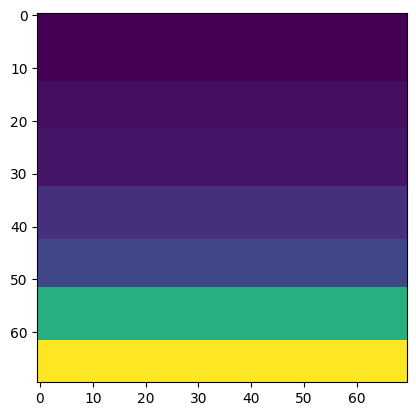

In [35]:
idx = 50
x = np.array(vel[idx,0,:,:])

fig = plt.figure()
plt.imshow(x), x.shape

In [43]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
class Generator(nn.Module):
    def __init__(self,latent_dim,img_shape):
        super(Generator, self).__init__()

        def block(in_feat, out_feat, normalize=True):
            layers = [nn.Linear(in_feat, out_feat)]
            if normalize:
                layers.append(nn.BatchNorm1d(out_feat, 0.8))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(latent_dim, 128, normalize=False),
            *block(128, 256),
            *block(256, 512),
            *block(512, 1024),
            nn.Linear(1024, int(np.prod(img_shape))),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), *img_shape)
        return img
    
class Discriminator(nn.Module):
    def __init__(self,img_shape):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(int(np.prod(img_shape)), 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)

        return validity    

In [44]:
# Loss function
adversarial_loss = torch.nn.BCELoss()

# Initialize generator and discriminator
latent_dim = 100
img_size = 70
channels = 1
img_shape = (channels, img_size, img_size)

generator = Generator(latent_dim,img_shape).to(device)
discriminator = Discriminator(img_shape).to(device)

# Optimizers
lr =1e-4
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr)
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr)


In [45]:
from torch.utils.data import Dataset, DataLoader

# 1. Define your Dataset class (if you haven't already):

class MyDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)  # Convert to torch tensor
        self.labels = torch.tensor(labels, dtype=torch.float32) #Convert labels to long for classification

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [46]:
from sklearn.model_selection import train_test_split

batch_size = 16
# data and labels to tensor
datainput = torch.tensor(vel,dtype=torch.float32)
labelout = torch.tensor(vel,dtype=torch.float32)


# Divide the data into train and test
train_data, test_data, train_labels, test_labels = train_test_split(
    datainput, labelout, test_size=0.1, random_state=42)

# Create your Dataset instance
dataset_train = MyDataset(train_data, train_labels)
dataset_test  = MyDataset(test_data, test_labels)

# Create a DataLoader
# Adjust batch_size as needed; shuffle=True for training

train_loader = torch.utils.data.DataLoader(dataset=dataset_train, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=dataset_test, 
                                          batch_size=batch_size, 
                                          shuffle=False)

/tmp/ipykernel_3648188/1364125503.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.data = torch.tensor(data, dtype=torch.float32)  # Convert to torch tensor
/tmp/ipykernel_3648188/1364125503.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.labels = torch.tensor(labels, dtype=torch.float32) #Convert labels to long for classification


In [ ]:

from torch.autograd import Variable
cuda = True if torch.cuda.is_available() else False
Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor

print("Start training GAE...")
epochs = 100

for epoch in range(epochs):
    glossall = 0
    dlossall = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        
        # Adversarial ground truths
        valid = Variable(Tensor(x.size(0), 1).fill_(1.0), requires_grad=False)
        fake = Variable(Tensor(x.size(0), 1).fill_(0.0), requires_grad=False)

        # Configure input
        real_imgs = Variable(x.type(Tensor))

        # -----------------
        #  Train Generator
        # -----------------

        optimizer_G.zero_grad()

        # Sample noise as generator input
        z = Variable(Tensor(np.random.normal(0, 1, (x.shape[0], latent_dim))))

        # Generate a batch of images
        gen_imgs = generator(z)

        # Loss measures generator's ability to fool the discriminator
        g_loss = adversarial_loss(discriminator(gen_imgs), valid)

        g_loss.backward()
        glossall+=g_loss
        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        # Measure discriminator's ability to classify real from generated samples
        real_loss = adversarial_loss(discriminator(real_imgs), valid)
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        dlossall+=d_loss
        optimizer_D.step()

    print(
        "[Epoch %d] [D loss: %f] [G loss: %f]"
        % (epoch, d_loss.item(), g_loss.item())
    )
    
print("Finish!!")

Start training GAE...
[Epoch 0] [D loss: 0.361993] [G loss: 0.665690]
[Epoch 1] [D loss: 0.397068] [G loss: 0.644651]
[Epoch 2] [D loss: 0.248072] [G loss: 0.996540]
[Epoch 3] [D loss: 0.317174] [G loss: 0.854134]
[Epoch 4] [D loss: 0.093037] [G loss: 1.790009]
[Epoch 5] [D loss: 0.068853] [G loss: 2.101600]
[Epoch 6] [D loss: 0.143108] [G loss: 1.527950]
[Epoch 7] [D loss: 0.217185] [G loss: 1.049621]
[Epoch 8] [D loss: 0.199040] [G loss: 1.121239]
[Epoch 9] [D loss: 0.031583] [G loss: 2.797760]
[Epoch 10] [D loss: 0.015091] [G loss: 3.517052]
[Epoch 11] [D loss: 0.051896] [G loss: 2.374792]
[Epoch 12] [D loss: 0.026659] [G loss: 3.101521]
[Epoch 13] [D loss: 0.052697] [G loss: 2.510542]
[Epoch 14] [D loss: 0.072504] [G loss: 2.007581]
[Epoch 15] [D loss: 0.018219] [G loss: 3.335262]
[Epoch 16] [D loss: 0.021951] [G loss: 3.215228]
[Epoch 17] [D loss: 0.009322] [G loss: 4.347004]
[Epoch 18] [D loss: 0.003340] [G loss: 5.043305]
[Epoch 19] [D loss: 0.005575] [G loss: 4.701358]
[Epoch 2

## Inference

In [ ]:
with torch.no_grad():
    # Sample noise as generator input
    z = Variable(Tensor(np.random.normal(0, 1, (x.shape[0], latent_dim))))

    # Generate a batch of images
    gen_imgs = generator(z)

In [ ]:
idx = 1
x = gen_imgs[idx]
x = x.view(70, 70)

fig = plt.figure()
plt.imshow(x.cpu().numpy())